# Sequential ViDA: Messidor → IDRiD → APTOS (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (Messidor-2)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Adapt to target domain (APTOS) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This tests if Messidor as source provides useful initialization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/messidor_idrid_aptos_visionfm.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: messidor2
Targets: ['idrid', 'aptos2019']
Method: cotta
Output: ./outputs/sequential_vida/messidor_idrid_aptos_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 20:45:46,542 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: messidor2 -> idrid -> aptos2019
2026-08-05 20:45:46,992 - src.models.visionfm_download - INFO - Downloading VisionFM Fundus weights from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=7f526948-0ce0-402a-88ba-b3350aedab21
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:23<00:00, 65.1MB/s]

2026-08-05 20:46:12,114 - src.models.visionfm_download - INFO - VisionFM Fundus weights downloaded to ./cache/visionfm/VFM_Fundus_weights.pth


2026-08-05 20:46:13,724 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-05 20:46:14,775 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-05 20:46:14,776 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-05 20:46:14,859 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-05 20:46:14,924 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-05 20:46:14,926 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-05 20:46:15,407 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 20:46:33,807 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=50.0
2026-08-05 20:46:33,810 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 1395 training samples (5 classes, 3072-dim features, T=50.0)
2

Adapting to messidor2:   0%|          | 0/22 [00:00<?, ?it/s]

...

Adapting to aptos2019:  96%|█████████▌| 22/23 [02:23<00:06,  6.33s/it, acc=0.4375, adaptations=22]

2026-08-05 20:52:42,482 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.0086, kl=0.0086, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to aptos2019: 100%|██████████| 23/23 [02:28<00:00,  6.47s/it, acc=0.2857, adaptations=23]

2026-08-05 20:52:42,769 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-08-05 20:53:04,388 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.6335
2026-08-05 20:53:04,391 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-08-05 20:53:04,484 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to aptos2019
2026-08-05 20:53:04,486 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on messidor2 (no adaptation)
2026-08-05 20:53:12,875 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.6062
2026-08-05 20:53:12,877 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 20:53:19,886 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.5494
2026-08-05 20:53:40,589 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.6335
2026-08-05 20:53:40,592 - src.evaluation.runner.sequential - INFO - 
2026-08-05 20:53:40,594 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

============== Sequential CTTA Results (ViDA VisionFM) ===============

Source domain: messidor2
  Baseline QWK:           0.4970
  Baseline Overall Acc:   55.59%

Target domains: idrid, aptos2019

----------------------------------------------------------------------
After adapting to source messidor2 (22/22 batches):
  QWK:                  0.6090  (delta: +0.1120)
  Overall Acc:          55.87% (delta: +0.29pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.5094
  Post-adaptation Acc on idrid: 35.92%
  Test on messidor2:
    QWK: 0.5890  (delta vs baseline: +0.0920)
    Acc: 56.73% (delta vs baseline: +1.15pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.6335
  Post-adaptation Acc on aptos2019: 36.89%
  Test on messidor2:
    QWK: 0.6062  (delta vs baseline: +0.1092)
    Acc: 55

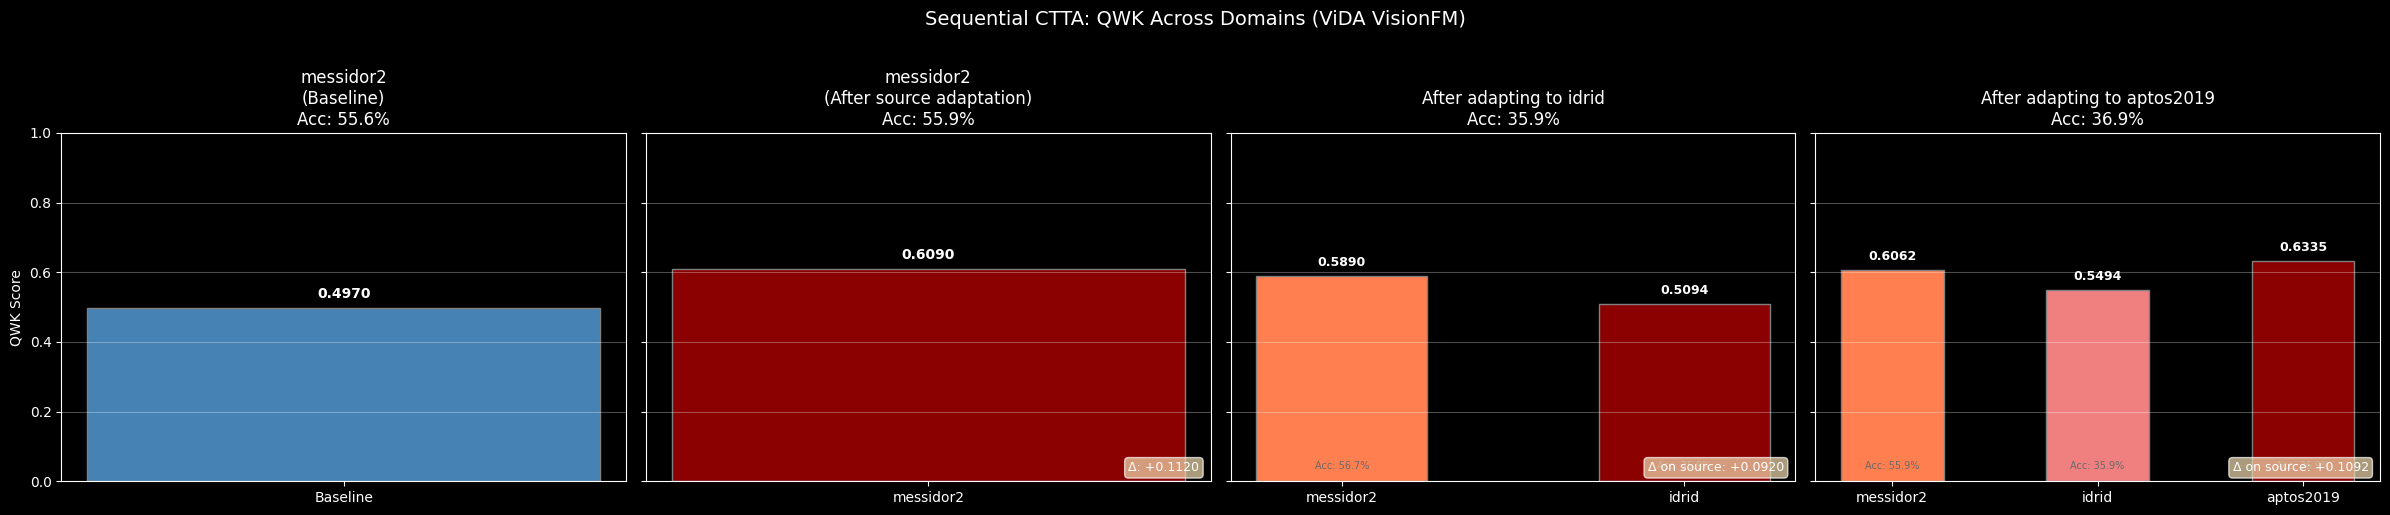

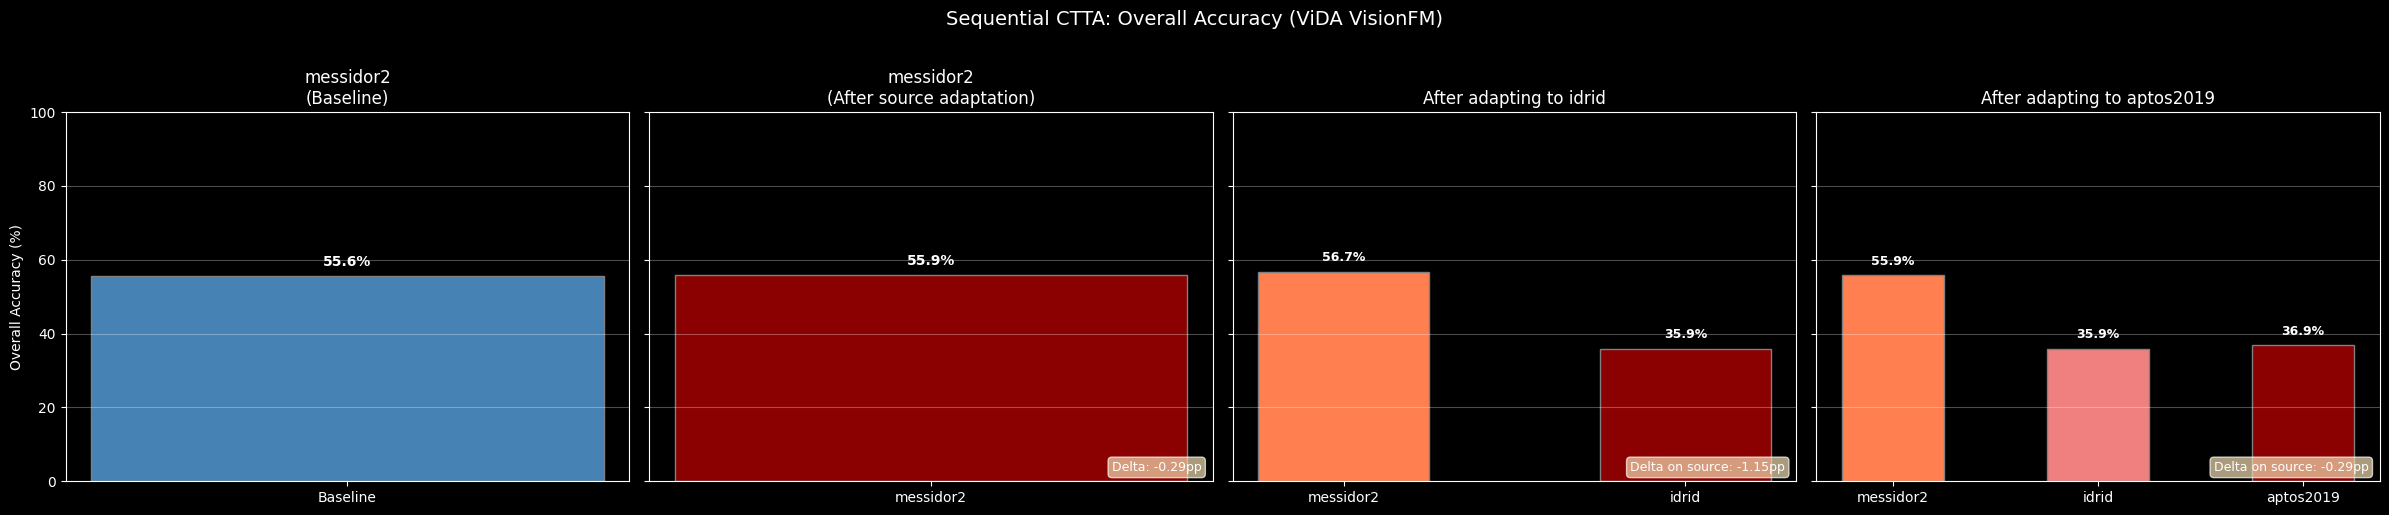

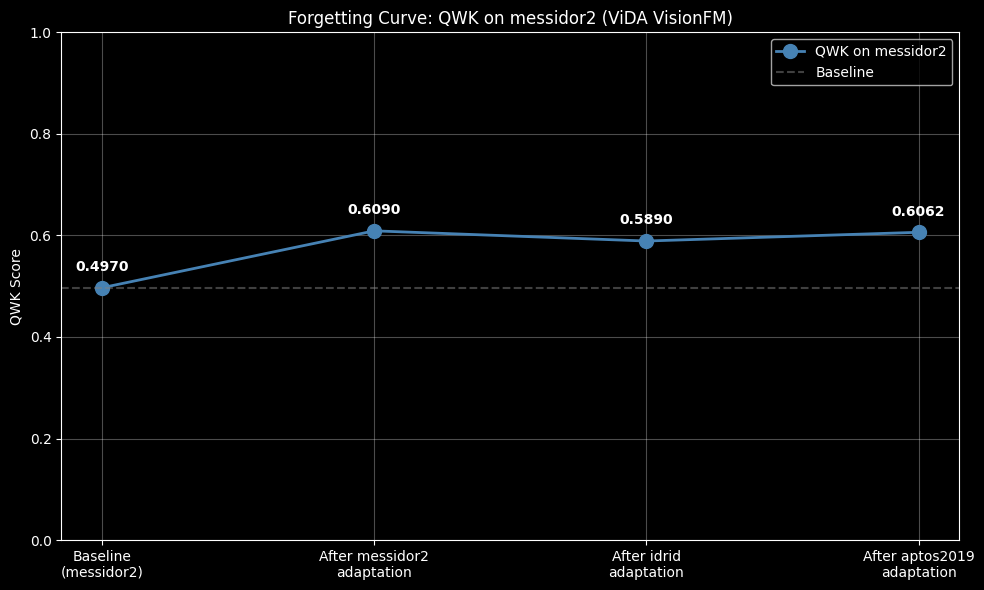

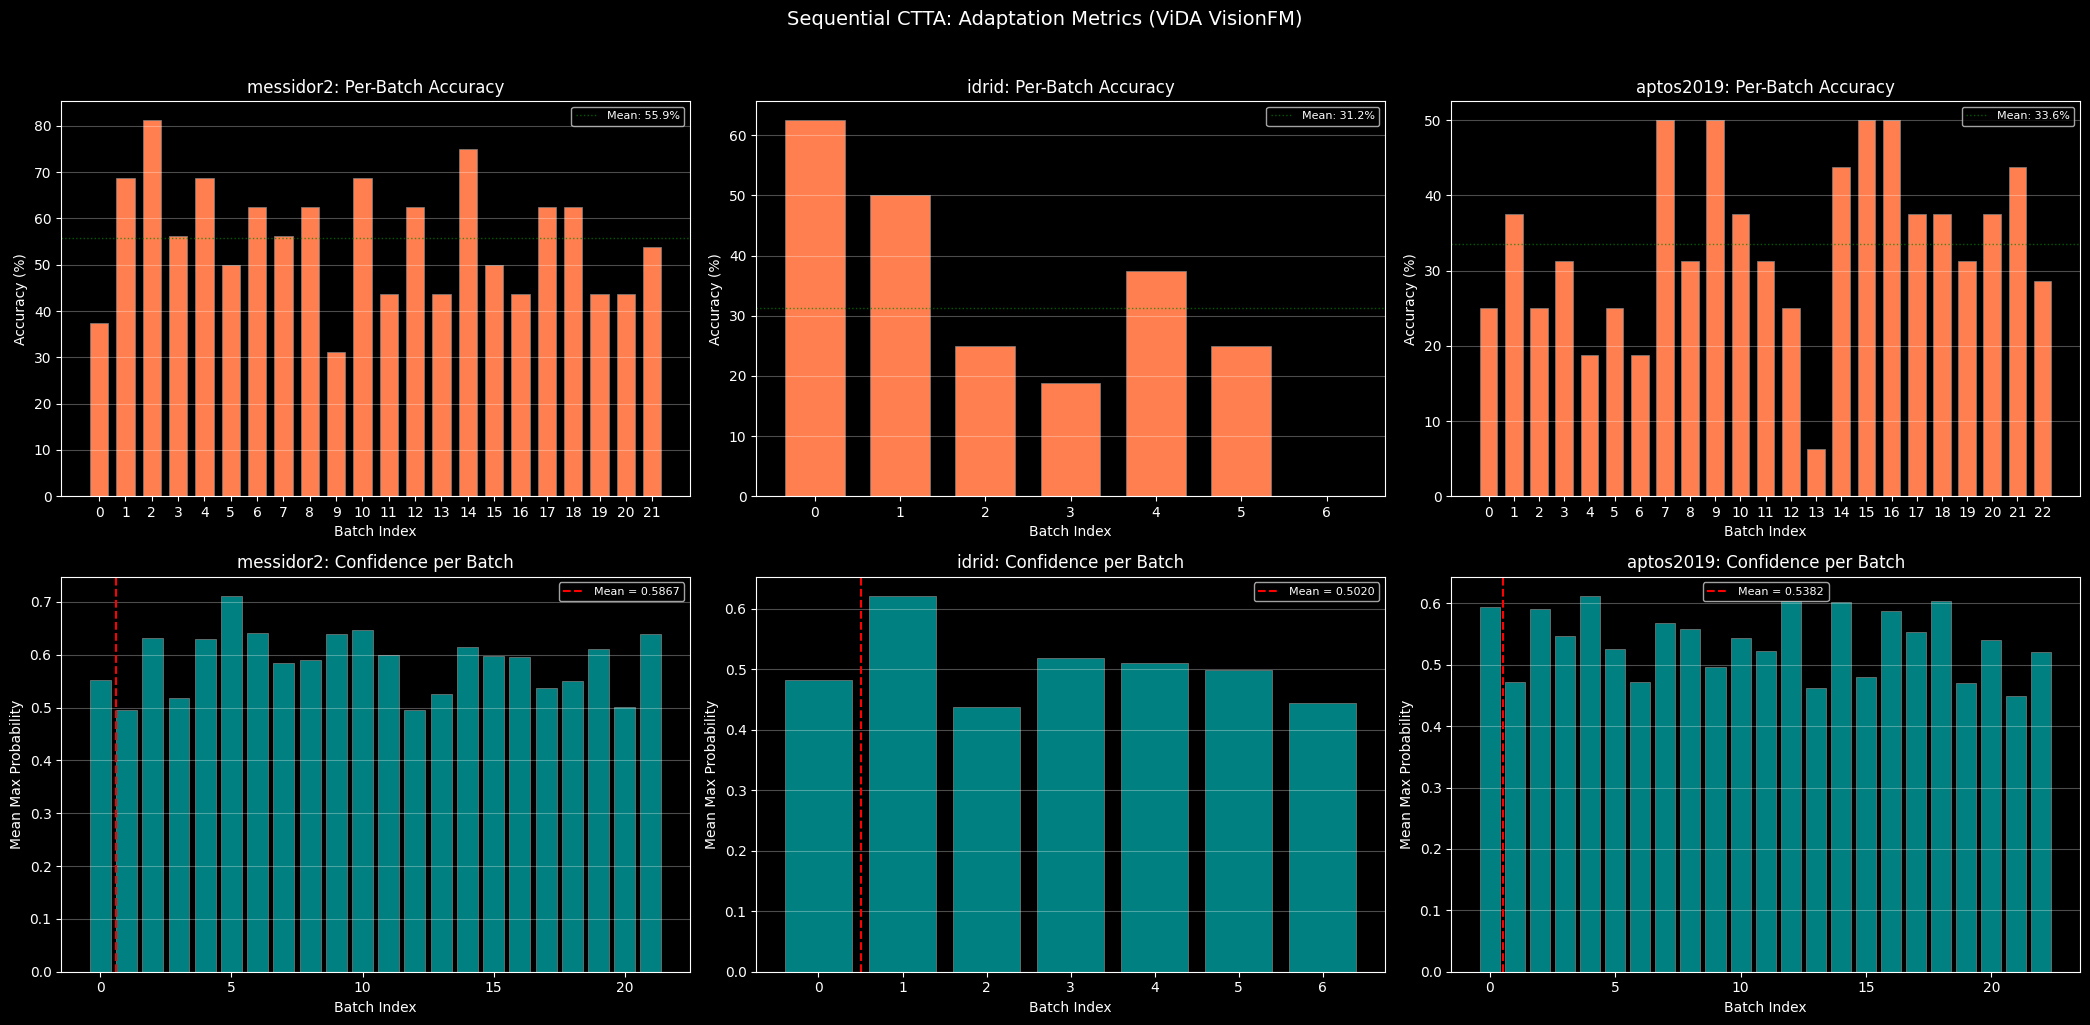

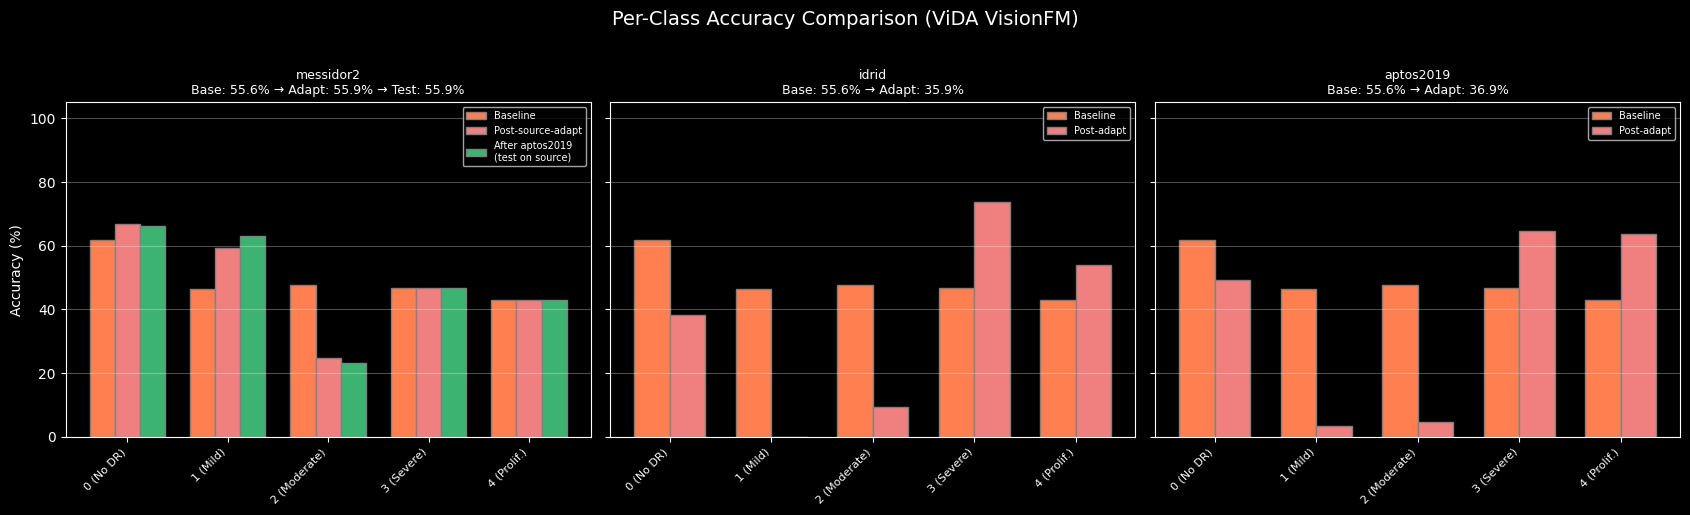

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'ViDA DINOv2' if config.model.name == 'retfound' else 'ViDA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)